In [6]:
from typing import TypedDict, Annotated, Optional
from langgraph.graph import add_messages, StateGraph, END, START
from langchain_groq import ChatGroq
from dotenv import load_dotenv
from langchain_community.tools.tavily_search import TavilySearchResults
from langgraph.checkpoint.memory import MemorySaver
from uuid import uuid4
import json

load_dotenv()

model = ChatGroq(model="llama-3.3-70b-versatile")


In [7]:
search_tool = TavilySearchResults(max_results=4)

tools = [search_tool]

memory = MemorySaver()



In [8]:
llm_with_tools = model.bind_tools(tools)



In [11]:
from langchain_core.messages import AIMessage, HumanMessage, ToolMessage

class State(TypedDict):
    messages: Annotated[list, add_messages]

async def model(state: State):
    result = await llm_with_tools.ainvoke(state["messages"])
    return {
        "messages": [result], 
    }

async def tools_router(state: State):
    last_message = state["messages"][-1]

    if(hasattr(last_message, "tool_calls") and len(last_message.tool_calls) > 0):
        return "tool_node"
    else: 
        return END
    
async def tool_node(state):
    """Custom tool node that handles tool calls from the LLM."""
    # Get the tool calls from the last message
    tool_calls = state["messages"][-1].tool_calls
    
    # Initialize list to store tool messages
    tool_messages = []
    
    # Process each tool call
    for tool_call in tool_calls:
        tool_name = tool_call["name"]
        tool_args = tool_call["args"]
        tool_id = tool_call["id"]
        
        # Handle the search tool
        if tool_name == "tavily_search_results_json":
            # Execute the search tool with the provided arguments
            search_results = await search_tool.ainvoke(tool_args)
            
            # Create a ToolMessage for this result
            tool_message = ToolMessage(
                content=str(search_results),
                tool_call_id=tool_id,
                name=tool_name
            )
            
            tool_messages.append(tool_message)
    
    # Add the tool messages to the state
    return {"messages": tool_messages}

graph_builder = StateGraph(State)

graph_builder.add_node("model", model)
graph_builder.add_node("tool_node", tool_node)
graph_builder.set_entry_point("model")

graph_builder.add_conditional_edges(
    "model",
    tools_router,
    {
        "tool_node": "tool_node",
        END: END
    }
)
graph_builder.add_edge("tool_node", "model")

graph = graph_builder.compile(checkpointer=memory)

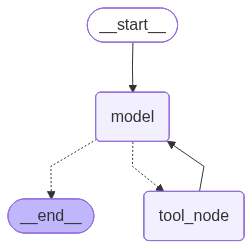

In [12]:
from IPython.display import Image, display
from langchain_core.runnables.graph import MermaidDrawMethod

display(
    Image(
        graph.get_graph().draw_mermaid_png(
            draw_method=MermaidDrawMethod.API
        )
    )
)

In [14]:
config = {
    "configurable": {
        "thread_id": 5
    }
}

response = await graph.ainvoke({
    "messages": [HumanMessage(content="When is the next spaceX launch?")], 
}, config=config)

response

{'messages': [HumanMessage(content='When is the next spaceX launch?', additional_kwargs={}, response_metadata={}, id='07d9c9b4-7c59-4d77-aa7e-6f04f867bb63'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': '7vxreg3vr', 'function': {'arguments': '{"query":"next SpaceX launch"}', 'name': 'tavily_search_results_json'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 20, 'prompt_tokens': 286, 'total_tokens': 306, 'completion_time': 0.053650231, 'completion_tokens_details': None, 'prompt_time': 0.015053579, 'prompt_tokens_details': None, 'queue_time': 0.057500328, 'total_time': 0.06870381}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_f8b414701e', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019cbef1-a117-7c71-b07a-80314807c29b-0', tool_calls=[{'name': 'tavily_search_results_json', 'args': {'query': 'next SpaceX launch'}, 'id': '7vxreg3vr', 'type': 't

In [20]:
config = {
    "configurable": {
        "thread_id": 6
    }
}
async for event in graph.astream_events({"messages": [HumanMessage(content="give me 300 words about : When is the next spaceX launch?")], }, config=config, version="v2"):
    if event["event"] == "on_chat_model_stream":
        print(event["data"]["chunk"].content, end="", flush=True)

The next SpaceX launch is scheduled to take place on March 4, 2026, with a Falcon 9 rocket carrying a batch of Starlink satellites. The launch is set to occur at 10:52 AM from Cape Canaveral Space Force Station in Florida. This mission aims to add more satellites to the Starlink constellation, which is a network of low-Earth orbit satellites designed to provide global internet connectivity.

SpaceX has been actively launching Starlink satellites over the past few years, with the goal of establishing a robust and reliable satellite network. The company has already launched numerous batches of Starlink satellites, and this upcoming launch is part of its ongoing efforts to expand the constellation.

The Falcon 9 rocket is a reusable launch vehicle that has been used for numerous SpaceX missions, including crewed flights to the International Space Station. The rocket is capable of carrying heavy payloads to low-Earth orbit and has a proven track record of success.

In addition to the Starl